**Installing the packages**

In [1]:
!pip install -q segmentation-models-pytorch timm albumentations opencv-python matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


**Importing the libraries**

In [2]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import torch.nn.functional as F
import segmentation_models_pytorch as smp

**Seting the image path. Image added manually**

In [3]:
img_path = "/content/test_image.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found: {img_path}")

print("Image found:", img_path)

Image found: /content/test_image.jpg


**Selecting the device**

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Defining the Cityscapes classes and colors**

In [5]:
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain',
    'sky', 'person', 'rider', 'car', 'truck', 'bus',
    'train', 'motorcycle', 'bicycle'
]

CITYSCAPES_COLORS = np.array([
    [128,  64, 128],  # road
    [244,  35, 232],  # sidewalk
    [ 70,  70,  70],  # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170,  30],  # traffic light
    [220, 220,   0],  # traffic sign
    [107, 142,  35],  # vegetation
    [152, 251, 152],  # terrain
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # person
    [255,   0,   0],  # rider
    [  0,   0, 142],  # car
    [  0,   0,  70],  # truck
    [  0,  60, 100],  # bus
    [  0,  80, 100],  # train
    [  0,   0, 230],  # motorcycle
    [119,  11,  32],  # bicycle
], dtype=np.uint8)

NUM_CLASSES = len(CITYSCAPES_CLASSES)
print("Number of classes:", NUM_CLASSES)

Number of classes: 19


**Creating the DeepLabV3+ model**

In [6]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
)

print("DeepLabV3+ model created successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

DeepLabV3+ model created successfully.


**Loading the trained checkpoint**

In [7]:
checkpoint_path = "/content/deeplabv3plus_cityscapes.pth"   # change if needed

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    cleaned_state_dict = {}
    for k, v in state_dict.items():
        new_k = k.replace("module.", "")
        cleaned_state_dict[new_k] = v

    model.load_state_dict(cleaned_state_dict, strict=False)
    print("Loaded trained checkpoint from:", checkpoint_path)
else:
    print("WARNING: No trained checkpoint found.")
    print("The code will run, but predictions will NOT be meaningful for the 19 road-scene classes.")
    print("For the report, use a trained DeepLabV3+ checkpoint.")

model = model.to(device)
model.eval()

The code will run, but predictions will NOT be meaningful for the 19 road-scene classes.
For the report, use a trained DeepLabV3+ checkpoint.


DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

**Loading and inspecting the image**

Original size: (319, 480, 3)


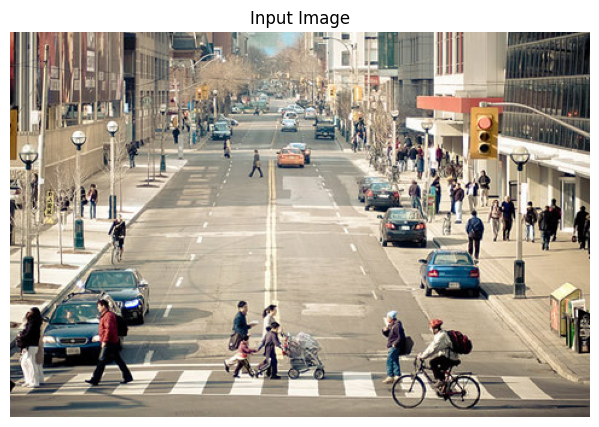

In [8]:
image = Image.open(img_path).convert("RGB")
image_np = np.array(image)
orig_h, orig_w = image_np.shape[:2]

print("Original size:", image_np.shape)

plt.figure(figsize=(8, 5))
plt.imshow(image_np)
plt.title("Input Image")
plt.axis("off")
plt.show()

**Preprocessed the image**

In [9]:
input_size = 512

image_resized = cv2.resize(image_np, (input_size, input_size))
image_resized = image_resized.astype(np.float32) / 255.0

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

image_norm = (image_resized - mean) / std
image_tensor = torch.tensor(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)

print("Tensor shape:", image_tensor.shape)

Tensor shape: torch.Size([1, 3, 512, 512])


**Running the DeepLabV3+ inference**

In [10]:
with torch.no_grad():
    logits = model(image_tensor)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([1, 19, 512, 512])


**Resized the prediction back to its original image size**

In [11]:
upsampled_logits = F.interpolate(
    logits,
    size=(orig_h, orig_w),
    mode="bilinear",
    align_corners=False
)

pred_mask = upsampled_logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)

print("Prediction mask shape:", pred_mask.shape)
print("Unique predicted class IDs:", np.unique(pred_mask))

Prediction mask shape: (319, 480)
Unique predicted class IDs: [13 14 15 16 18]


**Converted the predicted mask to color mask and overlay**

In [12]:
color_mask = CITYSCAPES_COLORS[pred_mask]
overlay = (0.6 * image_np + 0.4 * color_mask).astype(np.uint8)

**Supports the report’s proof-of-concept - Showing the results**

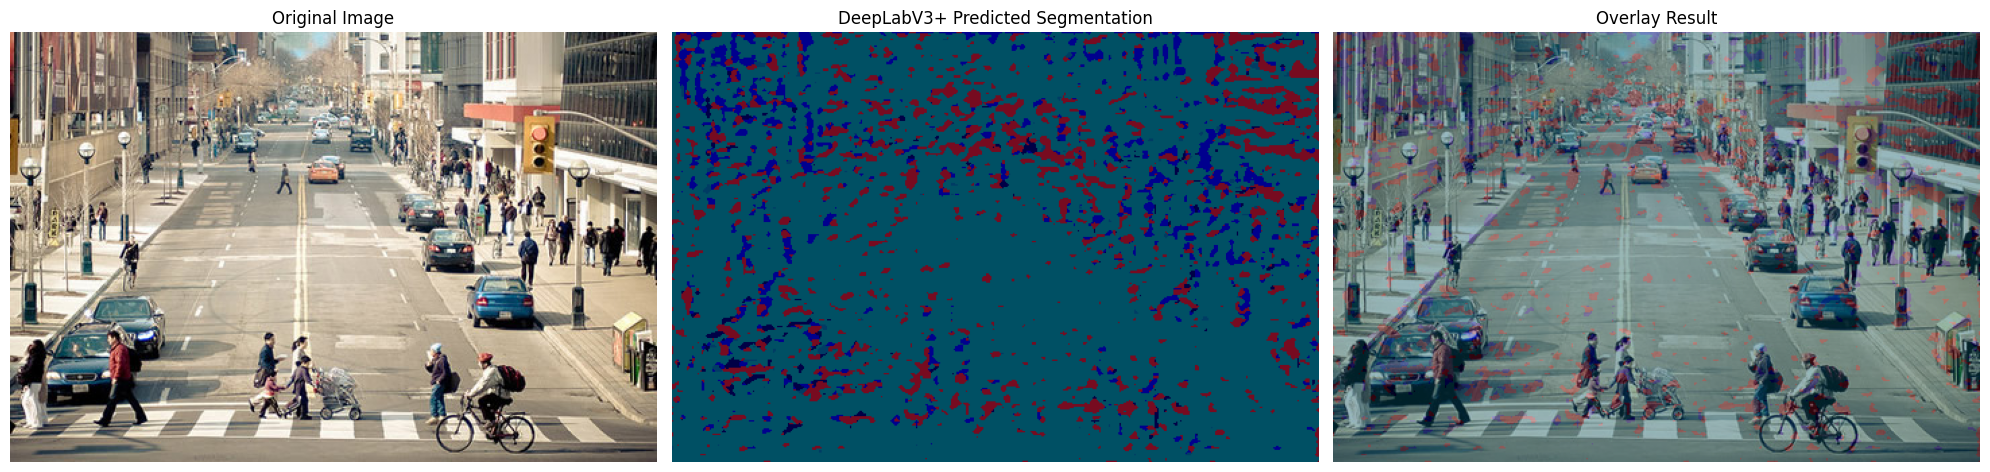

In [13]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(color_mask)
plt.title("DeepLabV3+ Predicted Segmentation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay Result")
plt.axis("off")

plt.tight_layout()
plt.show()

**Printing the predicted classes**

In [14]:
present_ids = np.unique(pred_mask)

print("\nClasses predicted in the image:")
for class_id in present_ids:
    if 0 <= class_id < len(CITYSCAPES_CLASSES):
        print(f"{class_id:2d}: {CITYSCAPES_CLASSES[class_id]}")


Classes predicted in the image:
13: car
14: truck
15: bus
16: train
18: bicycle


**Saving the mask and the overlay**

In [15]:
mask_save_path = "/content/deeplabv3plus_mask.png"
overlay_save_path = "/content/deeplabv3plus_overlay.png"

Image.fromarray(color_mask).save(mask_save_path)
Image.fromarray(overlay).save(overlay_save_path)

print("Saved mask to:", mask_save_path)
print("Saved overlay to:", overlay_save_path)

Saved mask to: /content/deeplabv3plus_mask.png
Saved overlay to: /content/deeplabv3plus_overlay.png


**Defining the IoU function**

In [16]:
import os
import cv2
import numpy as np
from PIL import Image

gt_mask_path = "/content/mask.png"

def compute_iou_per_class(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return ious

**Computing the IoU / mIoU and checking if the ground-truth mask exists**

In [17]:
if os.path.exists(gt_mask_path):
    gt_mask = np.array(Image.open(gt_mask_path))

    # Convert RGB ground-truth mask to class-index mask using Cityscapes colors
    if gt_mask.ndim == 3:
        gt_h, gt_w, _ = gt_mask.shape
        class_mask = np.zeros((gt_h, gt_w), dtype=np.int32)

        matched = np.zeros((gt_h, gt_w), dtype=bool)
        for class_id, color in enumerate(CITYSCAPES_COLORS):
            same = np.all(gt_mask == color, axis=-1)
            class_mask[same] = class_id
            matched |= same

        gt_mask = class_mask

    # Resize GT mask if needed
    if gt_mask.shape != pred_mask.shape:
        gt_mask = cv2.resize(
            gt_mask.astype(np.int32),
            (pred_mask.shape[1], pred_mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    pred_mask_eval = np.array(pred_mask).astype(np.int32)
    gt_mask_eval = np.array(gt_mask).astype(np.int32)

    num_classes_eval = NUM_CLASSES

    ious = compute_iou_per_class(pred_mask_eval, gt_mask_eval, num_classes_eval)
    miou = np.nanmean(ious)

    print("\nPer-class IoU:")
    for i, iou in enumerate(ious):
        class_name = CITYSCAPES_CLASSES[i] if i < len(CITYSCAPES_CLASSES) else f"Class {i}"
        if np.isnan(iou):
            print(f"{i:2d} ({class_name:15s}): N/A")
        else:
            print(f"{i:2d} ({class_name:15s}): {iou:.4f}")

    print(f"\nMean IoU (mIoU): {miou:.4f}")

else:
    print("No ground-truth mask found, so IoU was not computed.")

No ground-truth mask found, so IoU was not computed.
